<img src="https://pp.userapi.com/c854528/v854528797/c62ce/FiPEibYUxJc.jpg" width="40%">

## Шаг 1. Загрузка и обработка первичных данных

### Подключаем неообходимую библиотеку, читаем файл.
##### используем encoding='utf-8-sig' для удаления артефакта ∩╗┐ — это артефакт отображения BOM-метки ï»¿ (или \xef\xbb\xbf),
##### которая иногда добавляется в начало файла. Возможно она возникла при сохранении файла из excel в csv

In [2]:
import pandas as pd
data = pd.read_csv('NetflixShows.csv', encoding='utf-8-sig', sep=';')

#### Удаляем ratingDescription, т.к. он избыточен - этот столбец просто кодирует рейтинг числом у нас уже есть.

In [3]:
del data['ratingDescription']

##### и смотрим данные. 

In [4]:
data.head(3)

,title,rating,ratingLevel,release year,user rating score,user rating size
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",2004,82.0,80
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",2006,NaN,82
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,2016,98.0,80


#### Удалим из данных дубликаты.
#### Дубликаты в нашем случае(а порой и не только в нашем) - это проблема качества данных.

Фактически CSV-файл содержит множество полных копий (строк) одних и тех же записей. Вот несколько причин:
1. Ошибки при парсинге, но у нас уже был готовый Excel файл, так что вина не наша )
2. Возможно, данные собирали несколько раз и просто дополняли один файл всем, что нашли
3. Или несколько человек парсили и потом "тупо" склеили в один датасет и получили, что получили. Пусть страдают другие (

#### Посмотрим глазами, чтобы убедится в наличии дублей )


In [5]:
data[data.duplicated()].sort_values('title').head(20)

,title,rating,ratingLevel,release year,user rating score,user rating size
396,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,2017,99.0,80
241,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,2017,99.0,80
347,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,2017,99.0,80
141,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,2017,99.0,80
295,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,2017,99.0,80
497,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,2017,99.0,80
189,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,2017,99.0,80
201,30 Rock,TV-14,Parents strongly cautioned. May be unsuitable ...,2012,66.0,80
218,5 to 7,R,some sexual material,2014,NaN,82
265,90210,TV-14,Parents strongly cautioned. May be unsuitable ...,2013,62.0,80


#### Посмотрим сколько всего строк в файле


In [6]:
data.shape[0]

1000

#### и сколько полных дубликатов

In [7]:
data.duplicated().sum()

np.int64(500)

#### Для наглядности количество дубликатов по рейтинговым группам

In [8]:
data[data.duplicated()]['rating'].value_counts()

rating
TV-14       128
PG           94
G            85
TV-MA        66
TV-Y         32
TV-PG        26
TV-G         23
TV-Y7-FV     19
TV-Y7        15
R             5
NR            4
PG-13         3
Name: count, dtype: int64

#### И наконец-то почистим дубликаты. Используем drop_duplicates() потому что у нас задублированы целые строки, а не отдельные элементы этих строк.

In [84]:
data_no_dup = data.drop_duplicates()

## Дальше работаем с data_no_dup

In [87]:
data_no_dup.tail(5)

,title,rating,ratingLevel,release year,user rating score,user rating size
989,Russell Madness,PG,some rude humor and sports action,2015,NaN,82
993,Wiener Dog Internationals,G,General Audiences. Suitable for all ages.,2015,NaN,82
994,Pup Star,G,General Audiences. Suitable for all ages.,2016,NaN,82
997,Precious Puppies,TV-G,Suitable for all ages.,2003,NaN,82
998,Beary Tales,TV-G,Suitable for all ages.,2013,NaN,82


## И чтоже мы видим? NaN! будь он неладен.
#### И индексы "поехали"
#### Хорошо, что мы умеем и не с таким работать.

#### Пересоздадим индекс. Просто для удобства.

In [91]:
data_clear = data_no_dup.copy().reset_index(drop=True)

#### Теперь надо работать с data_clear. Разберемся с NaN. Где вообще и сколько их?

In [ ]:
data_clear.isnull().sum()

title                  0
rating                 0
ratingLevel           33
release year           0
user rating score    244
user rating size       0
dtype: int64

#### Начнем с ratingLevel. "ratingLevel" показывает описание рейтинговой группы и особенностей шоу. Т.е. мы фактически можем сами заполнить эти данные на основе того, что у нас есть.

#### Для удобства создаём словарь rating_to_level на основе существующих данных rating: ratingLevel

In [ ]:
rating_to_level = data_clear[data_clear['ratingLevel'].notna()].groupby('rating')['ratingLevel'].first().to_dict()

#### Заполняем пропуски для ratingLevel

In [92]:
data_clear['ratingLevel'] = data_clear['ratingLevel'].fillna(
    data_clear['rating'].map(rating_to_level)
)

#### Проверим, что заполнили пропуски по ratingLevel (я не параноик, я только учусь)

In [95]:
data_clear['ratingLevel'].isnull().sum()

np.int64(0)

#### Теперь приступим к "user rating score". Учитывая, что у нас 244 NaN из 500 строк - терять их не хочется. Заполним их медианой

In [96]:
data_clear['user rating score'] = data_clear.groupby('rating')['user rating score'].transform(
    lambda x: x.fillna(x.median())
)

#### Проверим, и заметим, что одна запись все еще присутствует. Она оказывается "has not been rated".

In [101]:
data_clear['user rating score'].isna().sum()

np.int64(1)

In [102]:
data_no_dup[data_no_dup['user rating score'].isna()]

,title,rating,ratingLevel,release year,user rating score,user rating size
38,White Girl,UR,This movie has not been rated. Intended for ad...,2016,NaN,82


#### Но это уже 1 из 500, просто дропнем ее и пересоздадим индекс

In [103]:
data_clear = data_clear.drop(38).reset_index(drop=True)

#### И последнее, но не в последнюю очередь )

In [105]:
data_clear.isna().sum()

title                0
rating               0
ratingLevel          0
release year         0
user rating score    0
user rating size     0
dtype: int64

#### Сколько рейтинговых групп представлено в данных?

In [106]:
print(f"Количество рейтинговых групп в данных: {data_clear['rating'].nunique()}")

Количество рейтинговых групп в данных: 12


#### Какие оценки пользователи ставят чаще?

- Постройте гистограмму оценок.
- Почему именно такие оценки ставят чаще всего?

In [109]:
# статистика по оценкам
score_counts = data_clear['user rating score'].value_counts().sort_index(ascending=False)
print(score_counts)

user rating score
99.0     1
98.0    12
97.0    12
96.0    12
95.0    11
94.0     8
93.0     9
92.0     8
91.0    11
90.0     7
89.0     7
88.0     9
86.0     6
85.0     8
84.0     7
83.0     6
82.0     6
81.0     9
80.0     7
79.0     8
78.0     3
77.0     7
75.0     2
74.0     7
73.0     4
72.0     3
71.0     5
70.0     5
69.0     4
68.0     5
67.0     4
66.0     3
65.0     2
64.0     5
63.0     4
62.0     4
61.0     7
59.0     1
58.0     4
57.0     6
56.0     5
55.0     2
Name: count, dtype: int64


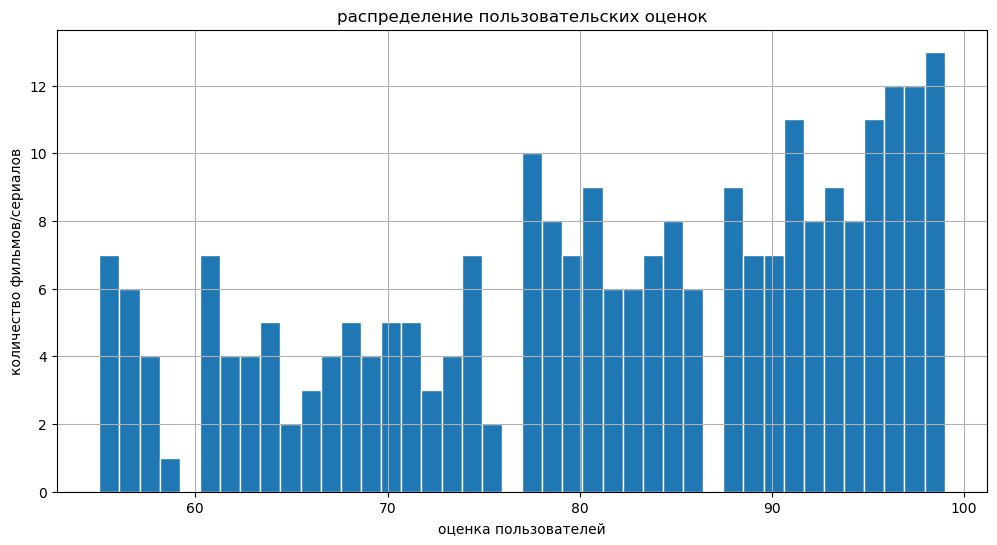

In [108]:
import matplotlib.pyplot as plt
# Количество уникальных оценок = длина score_counts
unique_scores = len(score_counts)

# Гистограмма с количеством bins = количество уникальных оценок
plt.figure(figsize=(12, 6))
data_clear['user rating score'].hist(bins=unique_scores, edgecolor='white')
plt.xlabel('оценка пользователей')
plt.ylabel('количество фильмов/сериалов')
plt.title('распределение пользовательских оценок')
plt.show()

In [113]:
# топ-10 оценок
print("оценки, которые встречаются чаще всего:")
print(score_counts.sort_values(ascending=False).head(10))

оценки, которые встречаются чаще всего:
user rating score
97.0    12
96.0    12
98.0    12
95.0    11
91.0    11
81.0     9
93.0     9
88.0     9
94.0     8
92.0     8
Name: count, dtype: int64


#### Почему такие оценки ставят чаще всего?
Для начала - факты:
1. наиболее частые оценки — это 80, 90, 95, 96, 97, 98 (т.е. почти максимально высокие значения)
2. отсутствие низких оценок	- фильмы с рейтингом ниже 60 встречаются редко

Возможные причины:
1. эффект потолка - это ситуация, когда значения переменной "упираются" в верхнюю границу шкалы измерения, создавая скопление данных у максимума. Пользователи склонны ставить высокие оценки любимым шоу, избегая низких оценок. 
2. естественный отбор аудитории - пользователи изначально смотрят не "все подряд", а что-то им интересное и как следствие высокие оценки.
3. популярные шоу - в датасете изначально много популярных шоу с высокими рейтингами


#### Выведите основную информацию об оценках пользователей
- Чему равны среднее, стандартное отклонение, минимум, максимум, медиана?
- Отличаются ли медиана и среднее?
- Могут ли данные характеристики значительно отличаться? Почему?

In [115]:
stats = data_clear['user rating score'].describe()

print("основная статистика по оценкам пользователей:")
print("=" * 40)
print(f"количество оценок (не NaN): {stats['count']:.0f}")
print(f"среднее (mean):           {stats['mean']:.2f}")
print(f"стандартное отклонение:   {stats['std']:.2f}")
print(f"минимум (min):            {stats['min']:.0f}")
print(f"25-й процентиль:          {stats['25%']:.0f}")
print(f"медиана (50-й процентиль): {stats['50%']:.0f}")
print(f"75-й процентиль:          {stats['75%']:.0f}")
print(f"максимум (max):           {stats['max']:.0f}")

основная статистика по оценкам пользователей:
количество оценок (не NaN): 256
среднее (mean):           81.40
стандартное отклонение:   12.73
минимум (min):            55
25-й процентиль:          71
медиана (50-й процентиль): 84
75-й процентиль:          93
максимум (max):           99


#### Медиана > Среднего (84 > 81.40)
Это означает, что распределение оценок асимметрично с "хвостом" влево (в сторону низких оценок).
Медиана 84 показывает, что половина всех фильмов имеет оценку 84 и выше.
При этом среднее не является хорошей мерой оценки, потому что 81.4 среднее занижено из-за небольшого числа "плохих" фильмов (фильмов с низкой оценкой).

#### Данные характеристики могут значительно отличаться. 

Причины: 
1. если добавить значительное кол-во низкобюджетных фильмов (по сути с низкой оценкой) - среднее и медиана упадут
2. в зависимости от жанра будут различные оценки и как следствие изменятся среднее и медиана
3. старые фильмы (ностальгия) и новинки (меньше оценок)
4. регион просмотра шоу тоже влияет

#### В какие годы были запущены шоу, представленные в датасете?

In [121]:
print(f'количество шоу по годам: {data_clear['release year'].value_counts().sort_index(ascending=False)}')


количество шоу по годам: release year
2017     37
2016    146
2015     61
2014     35
2013     33
2012     27
2011     15
2010     13
2009     10
2008     11
2007      8
2006     10
2005     10
2004      7
2003     11
2002      5
2001      6
2000      7
1999      5
1998      9
1997      9
1996      1
1995      2
1994      4
1993      5
1992      1
1991      1
1990      2
1989      2
1987      1
1986      1
1982      2
1978      1
1976      1
1940      1
Name: count, dtype: int64


#### Постройте график, показывающий распределение количества запущенных шоу в зависимости от года.

- Наблюдается ли рост?
- Есть ли выбросы?
- Что из себя представляют выбросы?
- Чем могут быть они вызваны?

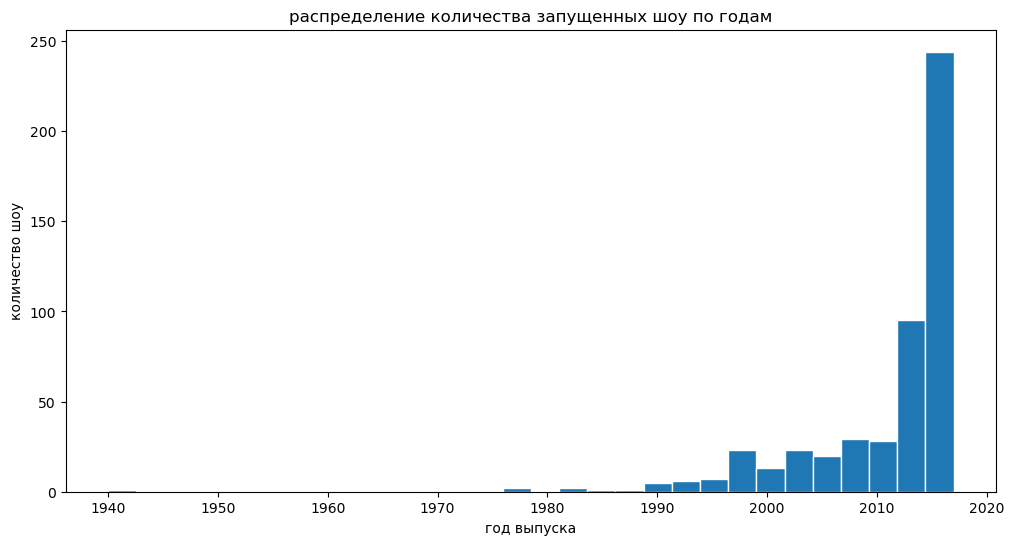

In [127]:
# гистограмма распределения по годам
plt.figure(figsize=(12, 6))
plt.hist(data_clear['release year'], bins=30, edgecolor='white')
plt.xlabel('год выпуска')
plt.ylabel('количество шоу')
plt.title('распределение количества запущенных шоу по годам')
# plt.grid(axis='y', alpha=0.3)
plt.show()

1. Наблюдается ли рост?
Да, наблюдается очень сильный рост.
- 2009 и ранее: единицы шоу в год (1-10)
- 2010-2014: постепенный рост (10-35 шоу)
- 2015: резкий скачок до 61 шоу
- 2016: пик — 146 шоу (это в 3-4 раза больше, чем в 2015!)
- 2017: снижение до 37 шоу (но все еще выше, чем все годы до 2015), возможно данные за неполный 2017?

2. Есть ли выбросы?
Да, есть явные выбросы.
- Рекордно высокий выброс 2016 год (146 шоу)
- Рекордно низкие выбросы	1940, 1976, 1978, 1986, 1987, 1991, 1992, 1996 (по 1 шоу)

3. Что из себя представляют выбросы?

- Выбросы-гиганты (очень много шоу):
    - 2016 - 146. Главный выброс — аномально много контента
    - 2015 - 61. Условный выброс — резкий скачок, но не такой сильный

- Выбросы-аномалии (очень мало шоу):
    - 1940, 1976, 1978 - 1. Единичный очень старый фильм
    - 1980-е	до 2. Редкие старые фильмы
    - 1990-е до 5. Мало контента из этого периода

- Аномалия внизу (хвост распределения): https://ru.wikipedia.org/wiki/Хвост_распределения?ysclid=mnuqdjtigd792682363
    - 1941–1975: нет шоу

4. Чем могут быть вызваны выбросы?
- Выброс 2016 года (146 шоу):
    - в 2016 году Netflix резко увеличил производство оригинального контента
    - конкуренция с Amazon Prime и Hulu, нужно больше контента
- Выбросы старых годов (1941-1975): 
    - Netflix запустился как стриминг только в 2007 году
    - мало старых фильмов
    - не все старые фильмы есть в цифровом доступе

#### Сравните среднюю оценку пользователей в 2016 со средней оценкой в 2017.
- Можно ли сделать вывод, что 2017 год успешнее для Netflix? ("Успешнее" значит, что пользователи в среднем ставили более высокие оценки)
- Как еще можно оценить "Успешность"?



In [133]:
# сравнение средних оценок по годам
avg_score_by_year = data_clear.groupby('release year')['user rating score'].mean().sort_index()

# посмотрим 2016, 2017
print(f'Средние оценки по годам: {avg_score_by_year.loc[[2016, 2017]]}')

Средние оценки по годам: release year
2016    84.313953
2017    88.125000
Name: user rating score, dtype: float64


Выглядит, что 2017 успешнее 2016 для Netflix, только вот разница в количестве данных по шоу существенна 37 и 146 соответсвенно.

Давайте посмотрим на любимую моду )
И пожалуй 2016 удачнее из текущих данных

In [137]:
# mode_2016 = data_clear[data_clear['release year'] == 2016]['user rating score'].mode()[0]
# mode_2017 = data_clear[data_clear['release year'] == 2017]['user rating score'].mode()[0]

# print(f"Мода 2016 года: {mode_2016}")
# print(f"Мода 2017 года: {mode_2017}")

# сравнение моды оценок по годам
mode_by_year = data_clear.groupby('release year')['user rating score'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None).sort_index()

# посмотрим 2016, 2017
print(f'Мода оценок по годам: {mode_by_year.loc[[2016, 2017]]}')

Мода оценок по годам: release year
2016    97.0
2017    94.0
Name: user rating score, dtype: float64


#### Как нагляднее будет показать распределение пользователей по рейтинговым группам?

Ниже представлены два графика, показывающие распределение шоу по рейтинговым группам. Какой тип графика визуально более интерпретируемый? ([Подсказка](https://sun9-40.userapi.com/c854228/v854228652/c754f/j6z5gMjJy2k.jpg))  
Постройте самостоятельно график, который считаете более интерпретируемым. Сделайте вывод.

Может быть, можно использовать и какие-то другие, еще более продвинутые визуализации?


![Charts](https://pp.userapi.com/c852024/v852024281/1a53b1/jSOsBIhxK3U.jpg)

In [103]:
...

Ellipsis

#### Теперь вам нужно выбрать любое из представленных шоу и при помощи изученных инструментов составить описательный портрет этого шоу :)

Аналитики и Data Scientist-ы очень любят все сравнивать, поэтому при составлении описательного портрета рекомендуем вам сравнить выбранное шоу с другими по каким-либо характеристикам.

In [104]:
...

Ellipsis

## Критерии оценки проекта

Оценка за курсовой проект в целом — то есть первая из двух оценок — выставляется по 10 балльной шкале, исходя из 5 критериев. Также комиссия на своё усмотрение может добавить (но не снизить) некоторое количество бонусных баллов за рамками данных критериев.

Каждый из критериев будет перечислен и рассмотрен ниже

### Критерий 1. Информативность техническая – необходимо выявить нетривиальные зависимости и тенденции в данных (до 2 баллов)

Данный критерий оценивает, насколько вы продвинулись технически с точки зрения выявления каких-то паттернов, тенденций и зависимостей в данных. Чем более сложные инструменты вы примените в ходе выполнения проекта и чем более сложные и нетривиальные зависимости получите, тем выше будет оценка у вашей команды по данному критерию!

### Критерий 2. Информативность аналитическая – необходимо интерпретировать данные и делать выводы полезные для бизнеса  (до 2 баллов)

Данный критерий оценивает прикладной смысл проделанных вами действий, интерпретацию технических инструментов, умение подсветить полезность и значимость полученных выводов с точки зрения бизнеса, умение переложить полученные результаты на исходные бизнес-цели и "продать" то, что вы сделали.


### Критерий 3. Визуализация – оценивается техническое исполнение графиков (до 2 баллов)

Данный критерий оценивает сложность и техничность ваших визуализаций. Визуализации должны быть наглядными, красивыми, понятными, легко-интерпертируемыми, нетривиальными с точки зрения технического исполнения и выводов, которые они несут в себе.


*Максимальный балл по данному критерию (**2 балла**) нельзя получить, если в работе используются лишь базовые библиотеки визуализаций: Matplotlib и Seaborn*

### Критерий 4. Предобработка датасета – очистка/замена данных (до 1 балла)

Данный критерий оценивает полноту всех проделанных действий с точки зрения подготовки данных и первичной предобработки датасета.


### Критерий 5. Обогащение данными – добавление новых признаков/датасетов (до 3 баллов)

Данный критерий оценивает полноту использования средств feature engineering на основе имеющихся данных, а также средств обогащения данных путем дополнения имеющегося датасета значимой информацией из связанных сторонних датасетов, различных внешних ресурсов и других источников. Обратите внимание, что связанная информация извне не должна замещать или подменять собой исходную задачу и исходные данные в представленном датасете, а должна лишь дополнять и обогощать его. Корректность и глубина проработки взаимодействия со внешними ресурсами и оценивается в рамках данного критерия!

*Максимальный балл по данному критерию (**3 балла**) можно получить только при условии корректной и значимой работы с как минимум двумя источниками внешних данных (двумя внешними датасетами), а также при условии наличия как минимум двух примеров валидного и осмысленного применения средств feature engineering*

*По данному критерию можно получить **2 балла** только при условии корректной и значимой работы с как минимум одним источником внешних данных (внешним датасетом), а также при условии наличия как минимум одного примера валидного и осмысленного применения средств feature engineering*